# Pi Approximation Using Monte Carlo Simulation

In this notebook, we will approximate $\pi$ using a Monte Carlo simulation.

In [41]:
import random
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from concurrent.futures import ThreadPoolExecutor
from scipy.stats import ttest_1samp, chi2

Let $X$ and $Y$ be two independent random variables both drawn from the
uniform distribution in the interval $[0, 1]$.

This way, the tuple $P := (X, Y)$ can be interpreted as a random point in the
first quadrant of the carterisan plane. Say we draw $N \geq 1$ of these points
and call them $P_i = (X_i, Y_i)$, for $i \in [1, N]$.

In [2]:
RANDOM_SEED = 42

random.seed(RANDOM_SEED)

In [3]:
def draw_random_point() -> tuple[float, float]:
    """Draw a random point in the first quadrant of the Cartesian plane."""
    return (random.uniform(0, 1), random.uniform(0, 1))

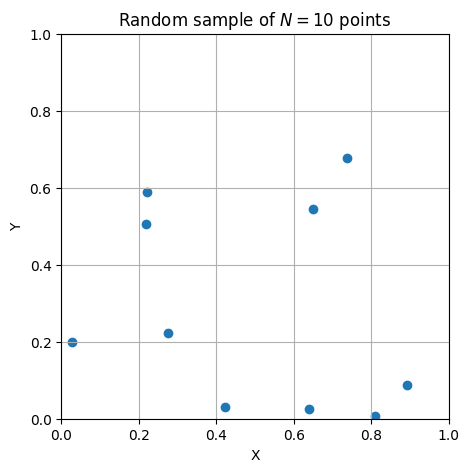

In [4]:
random_points_sample: list[tuple[int, int]] = [draw_random_point() for _ in range(10)]

fig, ax = plt.subplots(figsize=(5, 5))

for x, y in random_points_sample:
    ax.scatter(x, y, color="tab:blue")

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

ax.set_title(f"Random sample of $N =${len(random_points_sample)} points")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.grid(True)

Now, suppose that we check whether each of these $P_i$ points falls within the
unit circle. The equation of a circle with raidus 1 centered at $(0, 0)$ is
given by:

\begin{equation*}
    x^2 + y^2 = 1
\end{equation*}

Thus, $P_i$ lies inside the unit circle if and only if $X_i^2 + Y_i^2 \leq 1$.

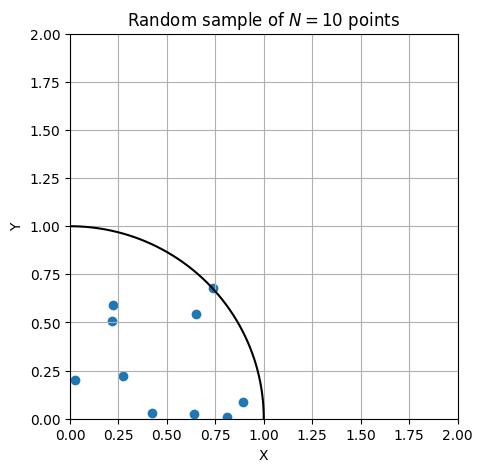

In [5]:
fig, ax = plt.subplots(figsize=(5, 5))

theta = np.linspace(0, np.pi / 2, 200)
ax.plot(np.cos(theta), np.sin(theta), color="black", linewidth=1.5)

for x, y in random_points_sample:
    ax.scatter(x, y, color="tab:blue")

ax.set_xlim(0, 2)
ax.set_ylim(0, 2)

ax.set_title(f"Random sample of $N =${len(random_points_sample)} points")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.grid(True)

Define an indicator random variable, $H_i$, such that it takes values 1 if
$X_i^2 + Y_i^2 \leq 1$ and 0 otherwise:

\begin{equation*}
    H_i := 1[X_i^2 + Y_i^2 \leq 1]
\end{equation*}

This is a Bernoulli random variable with probability $p$, where $p$ is the
probability that the point lands inside the unit circle.

From this, we can conclude the following results, which will be useful later
on:

\begin{equation*}
    E[H_i] = p
\end{equation*}

\begin{equation*}
    \begin{align*}
        Var[H_i] &= E[H_i^2] - E[H_i]^2 \\
        &= p - p^2 \\
        &= p (1 - p)
    \end{align*}
\end{equation*}

We know that $X_i$ is drawn from $\text{Uniform}(0, 1)$. Thus, it has pdf
$f_X$ given by:

\begin{equation*}
    f_X(x_i) =
    \begin{cases}
        1 & \text{if $0 \leq x_i \leq 1$} \\
        0 & \text{otherwise}
    \end{cases}
\end{equation*}

The same is true for $Y_i$, so it has the same pdf.

Because $X_i$ and $Y_i$ are
indepedent of each other, we also have that the joint pdf
$f_{X, Y}(x_i, y_i) = f_X(x_i) f_Y(y_i)$.

Using this, we can calculate $p = P[X_i^2 + Y_i^2 \leq 1]$:

\begin{equation*}
    \begin{align*}
       p &= P[X_i^2 + Y_i^2 \leq 1] \\
       &= P[Y_i^2 \leq 1 - X_i^2] \\
       &= \int_0^1 \int_0^{\sqrt{1 - x^2}} 1 \, dy dx \\
       &= \text{Area of a quarter of the unit circle} \\
       &= \frac{\pi}{4} \\
       &\approx 0.785
    \end{align*}
\end{equation*}

Now, define another random variable, $\bar{H}_N$, as the proportion of points
that fall inside the unit circle. We can write $\bar{H}_N$ in terms of the $H_i$:

\begin{equation*}
    \bar{H}_N = \frac{1}{N} \sum_{i=1}^N H_i
\end{equation*}

We can calculate the expected value of this random variable:

\begin{equation*}
    \begin{align*}
        E[\bar{H}_N] &= E\left[\frac{1}{N} \sum_{i=1}^N H_i\right] \\
        &= \frac{1}{N} \sum_{i=1}^N E[H_i] \\
        &= \frac{1}{N} \sum_{i=1}^N p \\
        &= p \\
        &= \frac{\pi}{4}
    \end{align*}
\end{equation*}

Similarly, we can find the variace:

\begin{equation*}
    \begin{align*}
        Var[\bar{H}_N] &= Var\left[\frac{1}{N} \sum_{i=1}^N H_i\right] \\
        &= \frac{1}{N^2} \sum_{i=1}^N Var[H_i] \\
        &= \frac{1}{N^2} \sum_{i=1}^N p (1 - p) \\
        &= \frac{p (1 - p)}{N} \\
        &= \frac{1}{N} \left(\frac{\pi}{4} \left(1 - \frac{\pi}{4}\right)\right)
    \end{align*}
\end{equation*}

By the Central Limit Theorem (CLT), as $N \to \infty$, $\bar{H}_N \xrightarrow{d} \mathcal{N}(E[\bar{H}_N], Var[\bar{H}_N])$.

Thus, if draw several $\bar{H_N}$ (for sufficiently large $N$), we expect the
result to be approximately normal.

A common rule of thumb that the normal approximation is adequate when both $Np$
and  $N(1−p)$ are at least some threshold, typically 10 or 30 depending on who
you ask.

If we take 30, then we can use the normal approximation as long as
$N \geq \frac{30}{1 - \pi / 4} \approx 139.8$

So, as long as our $N \geq 140$, we should be able to use the normal
approximation.

We will test a few different $N$ to show how the mean of the distribution stays the
same while the variance decreases for larger $N$. We will sample $M = 10,000$
$\bar{H}_N$ for each $N$ to visualize the distribution.

In [6]:
N = int(1e6)
num_simulations = int(1e4)

def simulate_batch(args):
    n, batch_size = args
    rng = np.random.default_rng()
    results = np.empty(batch_size)
    for i in range(batch_size):
        X = rng.uniform(0, 1, n)
        Y = rng.uniform(0, 1, n)
        results[i] = np.mean(X**2 + Y**2 <= 1)
    return results

num_workers = os.cpu_count()
batch_size = num_simulations // num_workers

with ThreadPoolExecutor(max_workers=num_workers) as executor:
    batches = list(executor.map(simulate_batch, [(N, batch_size)] * num_workers))

simulated_H_bar_1M = np.concatenate(batches)

In [7]:
N = int(1e5)

with ThreadPoolExecutor(max_workers=num_workers) as executor:
    batches = list(executor.map(simulate_batch, [(N, batch_size)] * num_workers))

simulated_H_bar_100k = np.concatenate(batches)

In [8]:
N = int(1e4)

with ThreadPoolExecutor(max_workers=num_workers) as executor:
    batches = list(executor.map(simulate_batch, [(N, batch_size)] * num_workers))

simulated_H_bar_10k = np.concatenate(batches)

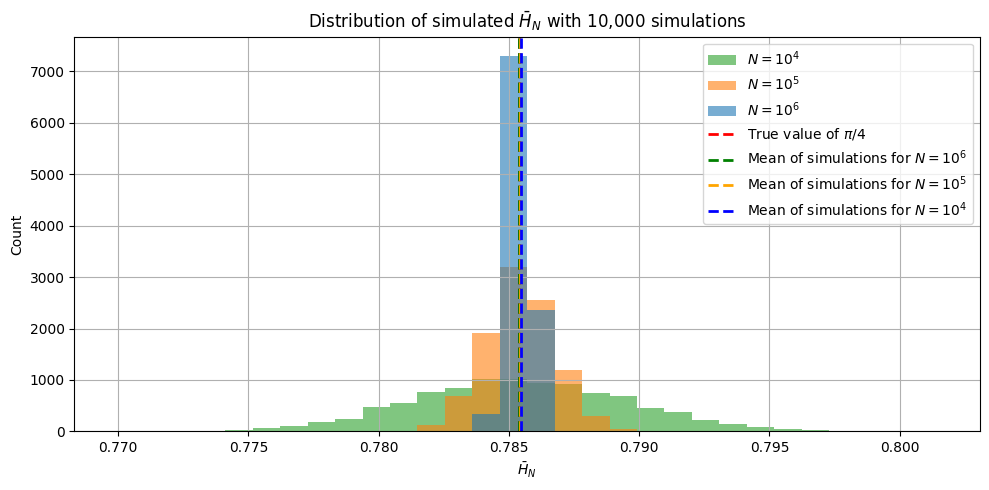

In [31]:
fig, ax = plt.subplots(figsize=(10, 5))

_, bins, _ = ax.hist(simulated_H_bar_10k, bins=30, density=False, alpha=0.6, color="tab:green", label="$N=10^4$")
ax.hist(simulated_H_bar_100k, bins=bins, density=False, alpha=0.6, color="tab:orange", label="$N=10^5$")
ax.hist(simulated_H_bar_1M, bins=bins, density=False, alpha=0.6, color="tab:blue", label="$N=10^6$")

ax.axvline(np.pi / 4, color="red", linestyle="dashed", linewidth=2, label="True value of $\\pi/4$")


ax.axvline(np.mean(simulated_H_bar_1M), color="green", linestyle="dashed", linewidth=2, label="Mean of simulations for $N=10^6$")
ax.axvline(np.mean(simulated_H_bar_100k), color="orange", linestyle="dashed", linewidth=2, label="Mean of simulations for $N=10^5$")
ax.axvline(np.mean(simulated_H_bar_10k), color="blue", linestyle="dashed", linewidth=2, label="Mean of simulations for $N=10^4$")

ax.set_title(f"Distribution of simulated $\\bar{{H}}_{{N}}$ with {num_simulations:,} simulations")
ax.set_xlabel("$\\bar{H}_N$")
ax.set_ylabel("Count")
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()

Since we have $M$ independent simulations of $\bar{H}_N$, we can use a
one-sample t-test, which does not assume the population variance is known.

Let $\bar{H}_N^{(1)}, \bar{H}_N^{(2)}, \dots, \bar{H}_N^{(M)}$ denote the
$M$ simulated values of $\bar{H}_N$. Define the sample mean and sample
variance as

\begin{equation*}
    \bar{X} = \frac{1}{M} \sum_{j=1}^{M} \bar{H}_N^{(j)}, \qquad
    S^2 = \frac{1}{M-1} \sum_{j=1}^{M} \left( \bar{H}_N^{(j)} - \bar{X} \right)^2
\end{equation*}

We have the following hypothesis testing problem:

\begin{equation*}
    \begin{cases}
        H_0: \mu = \frac{\pi}{4} \\
        H_1: \mu \neq \frac{\pi}{4}
    \end{cases}
\end{equation*}

Under $H_0$, the test statistic

\begin{equation*}
    T := \frac{\bar{X} - \frac{\pi}{4}}{S / \sqrt{M}} \sim t_{M-1}
\end{equation*}

follows a $t$-distribution with $M - 1$ degrees of freedom.

Say we significance level of $\alpha = 0.95$, meaning we reject $H_0$ is there
is less than a $5%$ change we would have gotten the data we did under $H_0$.

In [10]:
alpha = 0.05

t_stat_1M, p_value_1M = ttest_1samp(simulated_H_bar_1M, popmean=np.pi / 4)
t_stat_100k, p_value_100k = ttest_1samp(simulated_H_bar_100k, popmean=np.pi / 4)
t_stat_10k, p_value_10k = ttest_1samp(simulated_H_bar_10k, popmean=np.pi / 4)

print(f"Results for N=10^6: t-statistic = {t_stat_1M:.4f}, p-value = {p_value_1M:.4e}. Decision: {'Reject' if p_value_1M < alpha else 'Fail to reject'} the null hypothesis.")
print(f"Results for N=10^5: t-statistic = {t_stat_100k:.4f}, p-value = {p_value_100k:.4e}. Decision: {'Reject' if p_value_100k < alpha else 'Fail to reject'} the null hypothesis.")
print(f"Results for N=10^4: t-statistic = {t_stat_10k:.4f}, p-value = {p_value_10k:.4e}. Decision: {'Reject' if p_value_10k < alpha else 'Fail to reject'} the null hypothesis.")

Results for N=10^6: t-statistic = 0.7961, p-value = 4.2599e-01. Decision: Fail to reject the null hypothesis.
Results for N=10^5: t-statistic = 1.4671, p-value = 1.4238e-01. Decision: Fail to reject the null hypothesis.
Results for N=10^4: t-statistic = 1.2195, p-value = 2.2269e-01. Decision: Fail to reject the null hypothesis.


Now say we want to use this Monte Carlo simulation to estimate the value of
$\pi$ with at most an error of $\epsilon > 0$ and a probability of failure of
$\beta$.

First, define another random variable $W$:

\begin{equation*}
    W_N := 4 \bar{H}_N
\end{equation*}

By the properties of expectation and the CLT as used before:

\begin{equation*}
    E[W_N] = 4 E[\bar{H}_N] = \pi
\end{equation*}

\begin{equation*}
    Var[W_N] = 4^2 Var[\bar{H}_N] = \frac{16}{N} \left(\frac{\pi}{4} \left(1 - \frac{\pi}{4}\right)\right)
\end{equation*}

\begin{equation*}
    W_N \xrightarrow{d} \mathcal{N}(E[W_N], Var[W_N])
\end{equation*}

Now, we can express our situation with an equation:

\begin{equation*}
    P\left(|W_N - \pi| > \epsilon \right) = \beta
\end{equation*}

If we normalize $W_N$, we get a standard normal $Z$ and then we can solve for
$W_N - \pi$ in terms of $Z$:

\begin{equation*}
        Z = \frac{W_N - \pi}{\sqrt{\frac{16}{N} \left(\frac{\pi}{4} \left(1 - \frac{\pi}{4}\right)\right)}} \implies
        W_N - \pi = Z \sqrt{\frac{16}{N} \left(\frac{\pi}{4} \left(1 - \frac{\pi}{4}\right)\right)}
\end{equation*}

Let $\sigma^2 := 16 \left(\frac{\pi}{4} \left(1 - \frac{\pi}{4}\right)\right)$
for notational convenience.

Now we can express our probability in terms of $Z$:

\begin{equation*}
    \begin{align*}
        P\left(|W_N - \pi| > \epsilon \right) &= P\left(\left|Z \frac{\sigma}{\sqrt{N}}\right| > \epsilon \right) \\
        &= P\left(\left(Z \frac{\sigma}{\sqrt{N}}\right)^2 > \epsilon^2 \right) \\
        &= P\left(Z^2 \frac{\sigma^2}{N} > \epsilon^2 \right) \\
        &= P\left(Z^2 > \frac{N \epsilon^2}{\sigma^2}\right) = \beta
    \end{align*}
\end{equation*}

Since $Z \sim \mathcal{N}(0, 1)$, $Z^2 \sim \chi_1^2$ by the definition of the
chi-squared distribution.

In order to use the quantile function of the chi-squared distribution, we
can express our probability in terms of its complement:

\begin{equation*}
    P\left(Z^2 > \frac{N \epsilon^2}{\sigma^2}\right) = \beta \iff P\left(Z^2 \leq \frac{N \epsilon^2}{\sigma^2}\right) = 1 - \beta
\end{equation*}

The number $k$ that satisfies $P(Z^2 \leq k) = 1 - \beta$ is the $(1 - \beta)$
quantile of the chi-squared distribution with one degree of freedom. A
statistical package can give us this number.

Solving for the $N$ we need:

\begin{equation*}
    \frac{N \epsilon^2}{\sigma^2} = k \iff N = \frac{k \sigma^2}{\epsilon^2}
\end{equation*}

In [35]:
def calculate_N(epsilon: float, beta: float) -> int:
    assert 0 < beta < 1, "Beta must be between 0 and 1."
    k = chi2.ppf(1 - beta, df=1)
    sigma_squared = 4 * np.pi * (1 - np.pi / 4)
    return int(np.ceil((k * sigma_squared) / (epsilon ** 2)))

For example, if we want our estimate of $\pi$ to have an error of at most
$10^{-3}$ 90% of the times, we can calculate $N$ to be:

In [36]:
epsilon = 1e-3
beta = 0.10

N = calculate_N(epsilon, beta)

print(f"Required sample size N for epsilon={epsilon} and beta={beta}: {N:,}")

Required sample size N for epsilon=0.001 and beta=0.1: 7,296,219


Now, we can sample several $W_N$ with $N = 7,296,219$ and check that about 90%
do come within $10^{-3}$ of $\pi$.

In [26]:
with ThreadPoolExecutor(max_workers=num_workers) as executor:
    batches = list(executor.map(simulate_batch, [(N, batch_size)] * num_workers))

simulated_W_N = 4 * np.concatenate(batches)

In [28]:
satisfied = np.abs(simulated_W_N - np.pi) < epsilon
num_satisfied = np.sum(satisfied)

print(f"Proportion of simulations where |W_N - π| < {epsilon}: {num_satisfied / len(simulated_W_N):.4f} (Expected: {1 - beta:.4f})")

Proportion of simulations where |W_N - π| < 0.001: 0.9011 (Expected: 0.9000)


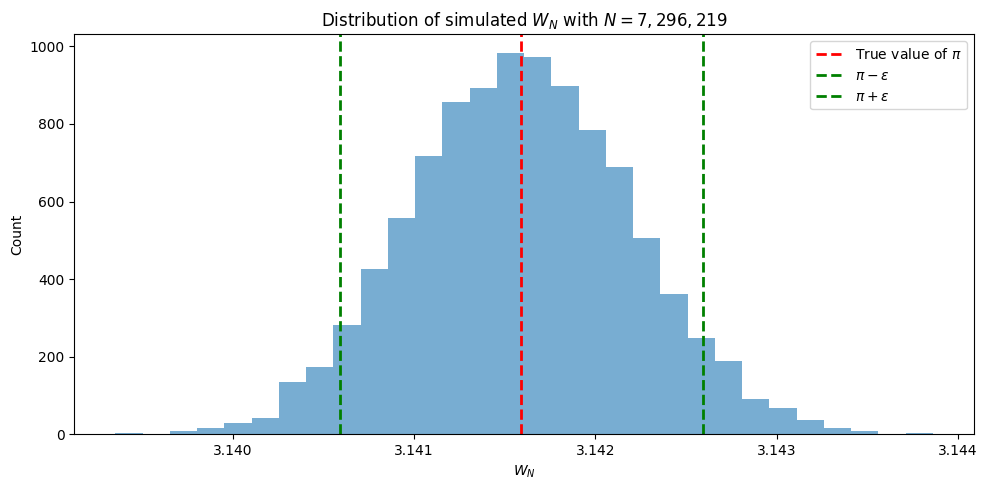

In [32]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(simulated_W_N, bins=30, density=False, alpha=0.6, color="tab:blue")

ax.axvline(np.pi, color="red", linestyle="dashed", linewidth=2, label="True value of $\\pi$")
ax.axvline(np.pi - epsilon, color="green", linestyle="dashed", linewidth=2, label=f"$\\pi - \\epsilon$")
ax.axvline(np.pi + epsilon, color="green", linestyle="dashed", linewidth=2, label=f"$\\pi + \\epsilon$")

ax.set_title(f"Distribution of simulated $W_{{N}}$ with $N={N:,}$")
ax.set_xlabel("$W_N$")
ax.set_ylabel("Count")
ax.legend()

plt.tight_layout()
plt.show()

Indeed, about 90% of the samples are within the required error bound.

In [39]:
epsilons = [0.1, 0.05, 0.01, 0.005, 0.001]
betas = [0.1, 0.05, 0.01, 0.001]

# Create the grid
data = []
for b in betas:
    row = [calculate_N(e, b) for e in epsilons]
    data.append(row)

# Create the DataFrame
df = pd.DataFrame(data, index=betas, columns=epsilons)
df.index.name = "Beta (Failure Prob)"
df.columns.name = "Epsilon (Error)"

print(df)

Epsilon (Error)      0.100  0.050   0.010    0.005     0.001
Beta (Failure Prob)                                         
0.100                  730   2919   72963   291849   7296219
0.050                 1036   4144  103596   414381  10359517
0.010                 1790   7158  178928   715711  17892765
0.001                 2920  11680  291995  1167977  29199415


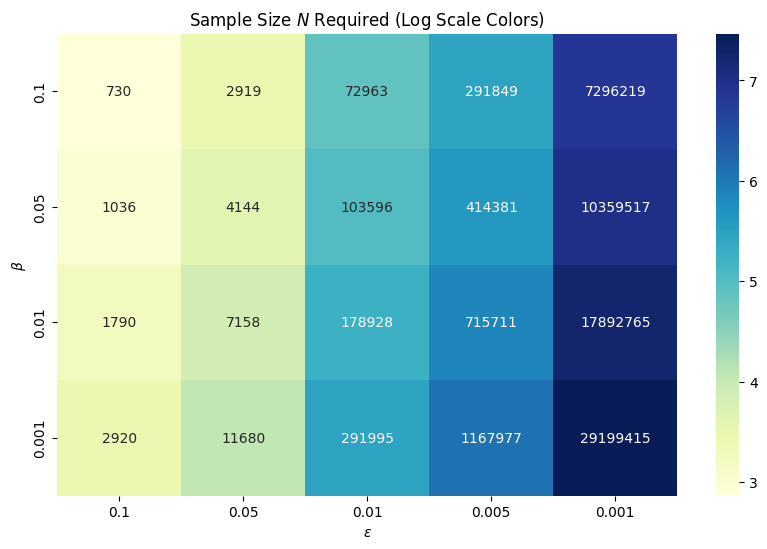

In [46]:
plt.figure(figsize=(10, 6))
# Using log10 to handle the huge variance in N values
sns.heatmap(np.log10(df), annot=df, fmt=".0f", cmap="YlGnBu")
plt.title("Sample Size $N$ Required (Log Scale Colors)")
plt.ylabel("$\\beta$")
plt.xlabel("$\\epsilon$")
plt.show()